Text(0.5, 1.0, '$50\\mu m$ Slit Mercury Arc Lamp')

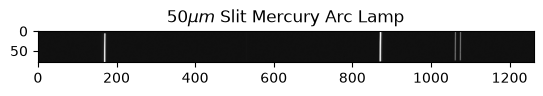

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import glob

# load the Mercury dark frames & create master dark
mercury_dark = []
for filename in glob.glob("ring_nebula/Dark-7s*"):
    dark_mercury_data = fits.getdata(filename)
    mercury_dark.append(dark_mercury_data)
master_dark_mercury = np.median(mercury_dark, axis=0)

# load the mercury arc lamp data & subtract background
mercury_data = []
for filename in glob.glob("ring_nebula/mercury-7s*"):
    data = fits.getdata(filename).astype(np.float64)
    data -= master_dark_mercury
    mercury_data.append(data)
combined_mercury = np.median(mercury_data, axis=0)
combined_mercury = combined_mercury[340:420, 300:]

plt.imshow(combined_mercury, cmap="grey", vmax=2000)
#plt.colorbar()
plt.title(r"$50\mu m$ Slit Mercury Arc Lamp")


Text(0.5, 1.0, '$50\\mu m$ Median Flat')

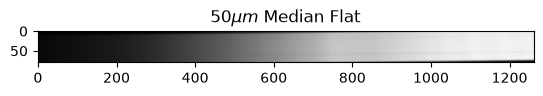

In [2]:
# make master dark for flats
dark_data_flats = []
for filename in glob.glob("ring_nebula/Dark-90s*"):
    data = fits.getdata(filename).astype(np.float64)
    dark_data_flats.append(data)
master_dark_arc_flats = np.median(dark_data_flats, axis=0)

# load flats and make master flat
mercury_flat_data = []
for filename in glob.glob("ring_nebula/Flat-90s-0C-20260915-04*"):
    data = fits.getdata(filename).astype(np.float64)
    data -= master_dark_arc_flats
    data = data[340:420, 300:]
    mercury_flat_data.append(data)
median_flat = np.median(mercury_flat_data, axis=0)

plt.imshow(median_flat, cmap="grey")
plt.title(r"$50\mu m$ Median Flat")

 [astropy.modeling.fitting]


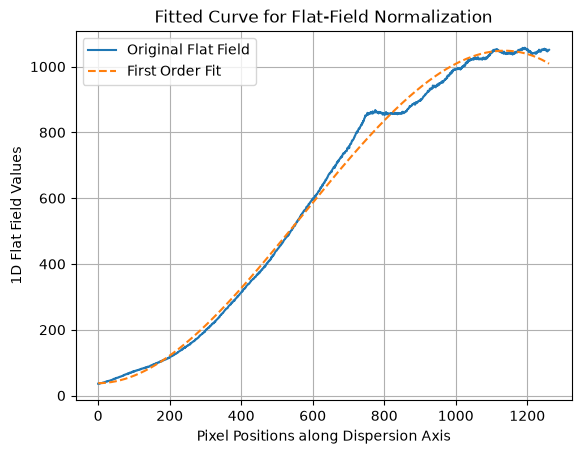

Text(0, 0.5, 'Counts of Number of Counts')

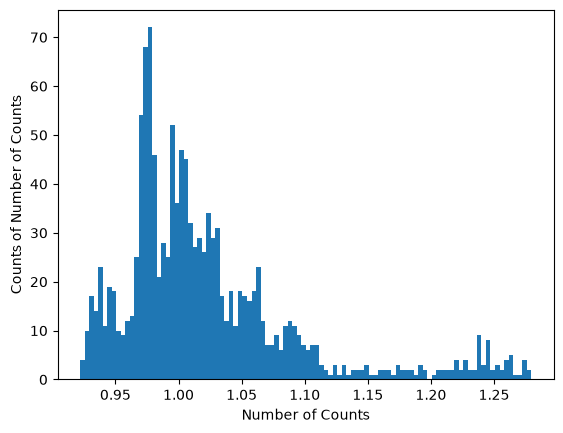

In [5]:
from astropy.modeling import models, fitting
dispersion_axis = np.arange(mercury_flat_data[0].shape[1])

# Initialize a fitting algorithm
fitter = fitting.LinearLSQFitter()

# 1D flat field response
flat_field_1d = np.median(median_flat, axis=0)

# Fit spectral response
dispersion_axis = np.arange(median_flat.shape[1])

polynomial_model = models.Polynomial1D(degree=5)
polynomial_fit = fitter(polynomial_model, dispersion_axis, flat_field_1d)
polynomial_curve_fit = polynomial_fit(dispersion_axis)

master_flat = median_flat / polynomial_curve_fit[None, :]
master_flat /= np.median(master_flat)

# Plot the original flat-field and the fitted curves
plt.plot(dispersion_axis, flat_field_1d, label='Original Flat Field')
plt.plot(dispersion_axis, polynomial_fit(dispersion_axis), label='First Order Fit', linestyle='--')
plt.xlabel('Pixel Positions along Dispersion Axis')
plt.ylabel('1D Flat Field Values')
plt.title('Fitted Curve for Flat-Field Normalization')
plt.legend()
plt.grid(True)
plt.show()

hist = plt.hist(np.median(master_flat, axis=0), bins=100)
plt.xlabel("Number of Counts")
plt.ylabel("Counts of Number of Counts")

/var/folders/74/9yc0dt9d53z15d2qpmgpxv4h0000gn/T/ipykernel_56678/1413733010.py:1: RuntimeWarning: divide by zero encountered in divide
  science_mercury = combined_mercury / master_flat
/var/folders/74/9yc0dt9d53z15d2qpmgpxv4h0000gn/T/ipykernel_56678/1413733010.py:1: RuntimeWarning: invalid value encountered in divide
  science_mercury = combined_mercury / master_flat


Text(0.5, 1.0, 'Mercury Pixel Spectrum')

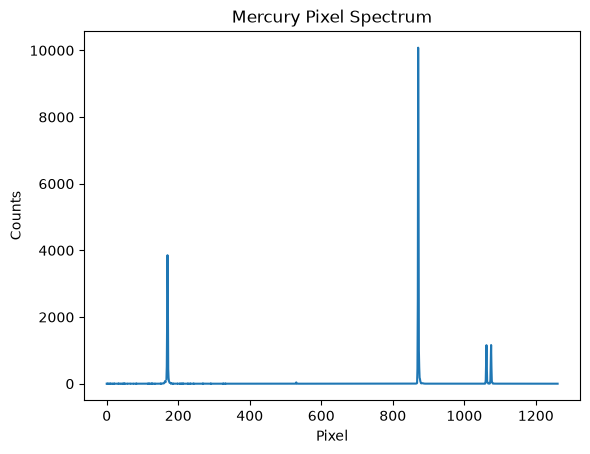

In [6]:
science_mercury = combined_mercury / master_flat
science_mercury_flat = np.median(science_mercury, axis=0)
plt.plot(science_mercury_flat)
plt.xlabel("Pixel")
plt.ylabel("Counts")
plt.title("Mercury Pixel Spectrum")

4
4
Model: Polynomial1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Degree: 1
Parameters:
            c0                 c1        
    ----------------- -------------------
    408.8332081309087 0.15814574181131646


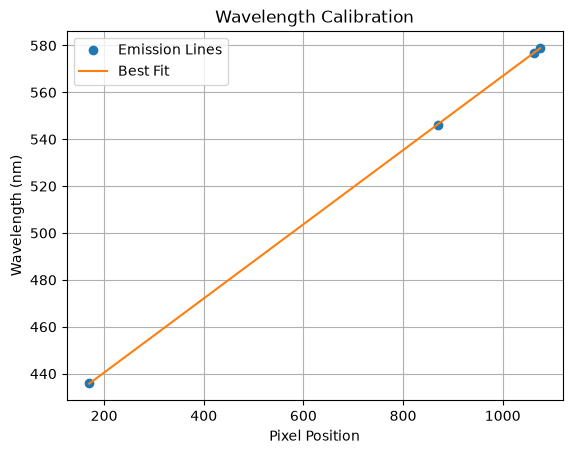

In [7]:
from scipy.signal import find_peaks
from astropy.modeling import models, fitting

# Find peaks corresponding to known wavelengths
peaks, _ = find_peaks(science_mercury_flat, height=1000.)
# Define the pixel positions of identified peaks
pixel_positions = peaks
print(len(pixel_positions))
# Known emission lines
known_wavelengths = [435.83, 546.07, 576.96, 579.06]
print(len(known_wavelengths))
# Define the model for fitting
linear_model = models.Polynomial1D(degree=1)
# Perform the fitting
fitter = fitting.LinearLSQFitter()
best_fit = fitter(linear_model, pixel_positions, known_wavelengths)
# Plot the data and the best-fit line
plt.plot(pixel_positions, known_wavelengths, 'o', label='Emission Lines')
plt.plot(pixel_positions, best_fit(pixel_positions), label='Best Fit')
plt.xlabel('Pixel Position')
plt.ylabel('Wavelength (nm)')
plt.title('Wavelength Calibration')
plt.grid(True)
plt.legend()
# Display the fit parameters
print(best_fit)
plt.show()

Text(5500, 4100, '5460 $\\rm \\AA$')

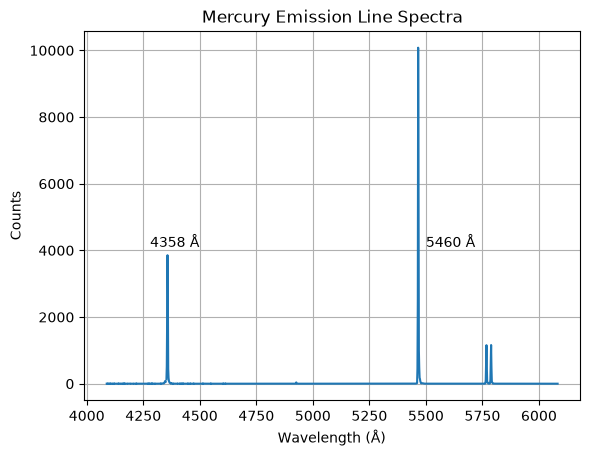

In [8]:
xs = np.arange(science_mercury.shape[1])
wavelength_axis = 408.8332081309087 + 0.15814574181131646*xs

plt.plot(wavelength_axis*10, science_mercury_flat)
plt.xlabel(r'Wavelength ($\rm \AA$)')
plt.ylabel('Counts')
plt.title('Mercury Emission Line Spectra')
plt.grid()

# annotate for lines
plt.annotate(
             xy=(4358, 4100),
             xytext=(4280, 4100),
             textcoords="data",
             text=r"4358 $\rm \AA$"
)
plt.annotate(
             xy=(5460, 4100),
             xytext=(5500, 4100),
             textcoords="data",
             text=r"5460 $\rm \AA$"
)

# Calibrate Vega Data

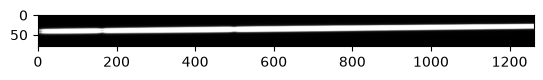

In [9]:
# master flats for Vega
dark_data_vega = []
for filename in glob.glob("ring_nebula/Dark-2-5s*"):
    data = fits.getdata(filename)
    dark_data_vega.append(data)
master_dark_vega = np.median(dark_data_vega, axis=0)

combined_data_vega = []
for filename in glob.glob("ring_nebula/Vega-2-5s*"):
    data = fits.getdata(filename).astype(np.float64)
    data -= master_dark_vega
    combined_data_vega.append(data)
combined_data_vega = np.mean(combined_data_vega, axis=0)
combined_data_vega = combined_data_vega[540:620, 300:]

plt.imshow(combined_data_vega, cmap="grey", vmax=2000)

/var/folders/74/9yc0dt9d53z15d2qpmgpxv4h0000gn/T/ipykernel_56678/4189835189.py:1: RuntimeWarning: divide by zero encountered in divide
  science_vega = combined_data_vega / master_flat


Text(4340, 205, 'H$\\gamma$ 4340$\\rm \\AA$')

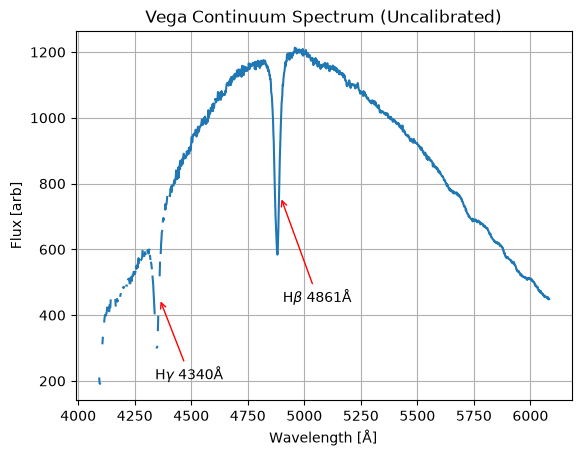

In [27]:
science_vega = combined_data_vega / master_flat
science_vega_1d = np.mean(science_vega, axis=0)

plt.plot(wavelength_axis*10, science_vega_1d)
plt.xlabel(r"Wavelength [$\rm \AA$]")
plt.ylabel("Flux [arb]")
plt.title("Vega Continuum Spectrum (Uncalibrated)")
plt.grid()

# annotate arrows for lines
plt.annotate(
             xy=(4895, 760),
             xytext=(4905, 440),  # text above
             textcoords="data",
             arrowprops=dict(arrowstyle="->", color="red"),
             text=r"H$\beta$ 4861$\rm \AA$"
)
plt.annotate(
             xy=(4360, 450),
             xytext=(4340, 205),  # text above
             textcoords="data",
             arrowprops=dict(arrowstyle="->", color="red"),
             text=r"H$\gamma$ 4340$\rm \AA$"
)

# Ring Nebula

/var/folders/74/9yc0dt9d53z15d2qpmgpxv4h0000gn/T/ipykernel_56678/2867134164.py:8: RuntimeWarning: divide by zero encountered in divide
  science_ring = combined_data_ring / master_flat


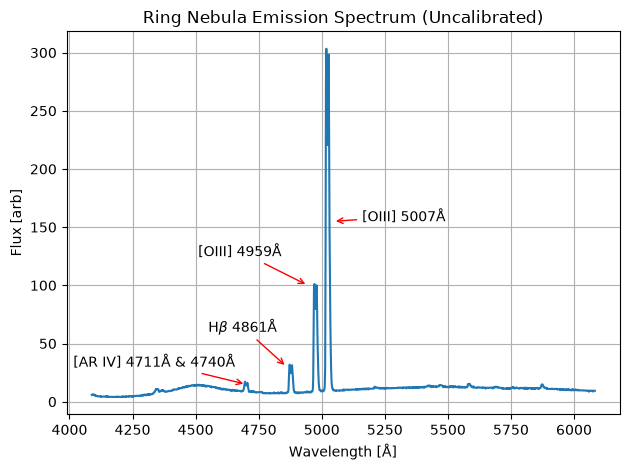

In [26]:
ring_data = []
for filename in glob.glob("ring_nebula/m57-900s*"):
    data = fits.getdata(filename)
    ring_data.append(data)
combined_data_ring = np.median(ring_data, axis=0)
combined_data_ring = combined_data_ring[540:620, 300:]

science_ring = combined_data_ring / master_flat
science_ring_1d = np.median(science_ring, axis=0)

plt.plot(wavelength_axis * 10, science_ring_1d)
plt.xlabel(r"Wavelength [$\rm \AA$]")
plt.ylabel("Flux [arb]")
plt.title("Ring Nebula Emission Spectrum (Uncalibrated)")
plt.grid()

# annotate arrows for lines
plt.annotate(
             xy=(5045, 155),
             xytext=(5160, 155),  # text above
             textcoords="data",
             arrowprops=dict(arrowstyle="->", color="red"),
             text=r"[OIII] 5007$\rm \AA$"
)
plt.annotate(
             xy=(4945, 100),
             xytext=(4510, 125),  # text above
             textcoords="data",
             arrowprops=dict(arrowstyle="->", color="red"),
             text=r"[OIII] 4959$\rm \AA$"
)
plt.annotate(
             xy=(4861, 30),
             xytext=(4550, 60),  # text above
             textcoords="data",
             arrowprops=dict(arrowstyle="->", color="red"),
             text=r"H$\beta$ 4861$\rm \AA$"
)
plt.annotate(
             xy=(4700, 15),
             xytext=(4015, 30),  # text above
             textcoords="data",
             arrowprops=dict(arrowstyle="->", color="red"),
             text=r"[AR IV] 4711$\rm \AA$ & 4740$\rm \AA$"
)

plt.tight_layout()
plt.show()